## ResNet50

In [1]:
import os   ### For working of CUDA #

# Disable XLA completely
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda"
os.environ["TF_DISABLE_XLA"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications.resnet import ResNet50, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# Constants - change if you want
IMG_SIZE = 224
BATCH_SIZE = 16            # lower if OOM; increase if GPU allows
AUTOTUNE = tf.data.AUTOTUNE
SEED = 1


## Loading Preprocessed Data

In [3]:

df = pd.read_csv("../data/processed/manifest.csv")
df.head()

# Ensure columns: image_path,label,video_id,split
print(df.columns.tolist())

# Quick check: videos appearing in more than one split
dup = df.groupby("video_id")["split"].nunique()
leak_videos = dup[dup > 1]
print("Videos present in >1 split (should be zero):", len(leak_videos))
if len(leak_videos):
    print(leak_videos.head())


['image_path', 'label', 'video_id', 'split']
Videos present in >1 split (should be zero): 0


In [4]:

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

train_paths = train_df["image_path"].values
train_labels = train_df["label"].astype(int).values

val_paths = val_df["image_path"].values
val_labels = val_df["label"].astype(int).values

test_paths = test_df["image_path"].values
test_labels = test_df["label"].astype(int).values


print("Counts (frames) -> train/val/test:", len(train_df), len(val_df), len(test_df))
print("Class balance in train:\n", train_df['label'].value_counts())


Counts (frames) -> train/val/test: 907 204 302
Class balance in train:
 label
0    674
1    233
Name: count, dtype: int64


# Preprocessing

In [ ]:

def load_and_preprocess(path, label):
    # path: string tensor
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.05)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label


def preprocess(img, label):
    img = preprocess_input(img)  
    return img, label


# TRAIN DS
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(len(train_paths), seed=SEED)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# VAL DS
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# TEST DS
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


2025-12-01 15:28:29.310665: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2025-12-01 15:28:29.310894: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:287] kernel version 580.95.5 does not match DSO version 580.105.8 -- cannot find working devices in this configuration


## Compute Class weight (imbalance)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_labels)
class_weights = compute_class_weight('balanced', classes=classes, y=train_labels)
class_weights = {int(c): float(w) for c,w in zip(classes, class_weights)}
print("Class weights:", class_weights)


Class weights: {0: 0.6728486646884273, 1: 1.946351931330472}


## RESNET50 feature extractor head

In [ ]:
base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False   # freeze

x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Train head on frozen base

In [ ]:
checkpoint_path = "resnet_stage1_best.h5"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.5688 - loss: 0.7262
Epoch 1: val_loss improved from None to 0.86023, saving model to resnet_stage1_best.h5


57/57 ━━━━━━━━━━━━━━━━━━━━ 47s 764ms/step - accuracy: 0.6549 - loss: 0.6390 - val_accuracy: 0.2353 - val_loss: 0.8602 - learning_rate: 1.0000e-04
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.7732 - loss: 0.4611
Epoch 2: val_loss did not improve from 0.86023
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 727ms/step - accuracy: 0.8004 - loss: 0.4112 - val_accuracy: 0.3627 - val_loss: 0.9844 - learning_rate: 1.0000e-04
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.8639 - loss: 0.3297
Epoch 3: val_loss did not improve from 0.86023
57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 736ms/step - accuracy: 0.8666 - loss: 0.3128 - val_accuracy: 0.3529 - val_loss: 1.0052 - learning_rate: 1.0000e-04
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.8969 - loss: 0.2643
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 4: val_loss did not improve from 0.86023
57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 734ms/step - accuracy: 0.8964 - loss: 0.2634 - val_accu

## Stage one curves

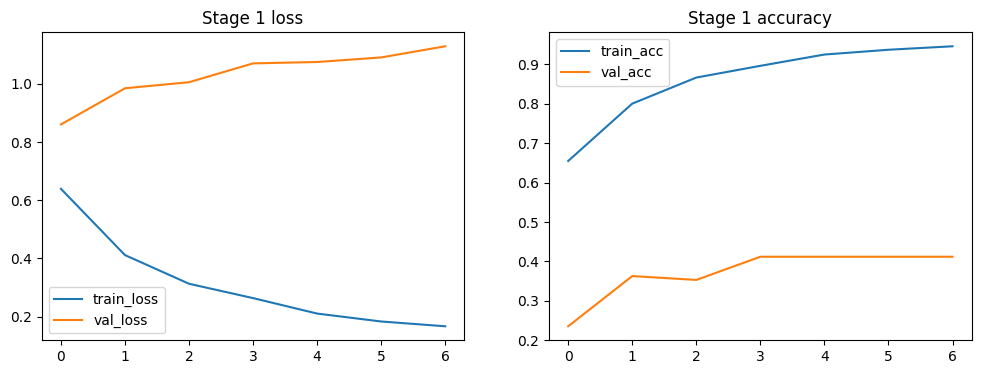

In [ ]:
def plot_history(h, title="History"):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.legend(); plt.title(title + " loss")
    plt.subplot(1,2,2)
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.legend(); plt.title(title + " accuracy")
    plt.show()

plot_history(history_stage1, "Stage 1")


## Fine Tuning (unfreeze last layers)

In [ ]:
# Unfreeze last N layers
N = 50   # try 30 or 50; adjust if OOM
for layer in base.layers[:-N]:
    layer.trainable = False
for layer in base.layers[-N:]:
    layer.trainable = True

# Recompile with lower LR
model.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_path_ft = "resnet_finetuned_best.h5"
callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(checkpoint_path_ft, monitor='val_loss', save_best_only=True, verbose=1)
]

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_ft
)


Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8520 - loss: 0.5929
Epoch 1: val_loss improved from None to 0.96390, saving model to resnet_finetuned_best.h5


57/57 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9151 - loss: 0.3649 - val_accuracy: 0.4069 - val_loss: 0.9639 - learning_rate: 1.0000e-05
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9796 - loss: 0.1163
Epoch 2: val_loss did not improve from 0.96390
57/57 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9846 - loss: 0.1024 - val_accuracy: 0.4902 - val_loss: 1.1368 - learning_rate: 1.0000e-05
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9953 - loss: 0.0601
Epoch 3: val_loss did not improve from 0.96390
57/57 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9967 - loss: 0.0511 - val_accuracy: 0.4951 - val_loss: 1.2599 - learning_rate: 1.0000e-05
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9989 - loss: 0.0330
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 4: val_loss did not improve from 0.96390
57/57 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9967 - loss: 0.0295 - val_accuracy: 0.4951 - val_lo

## Stage 2 plot

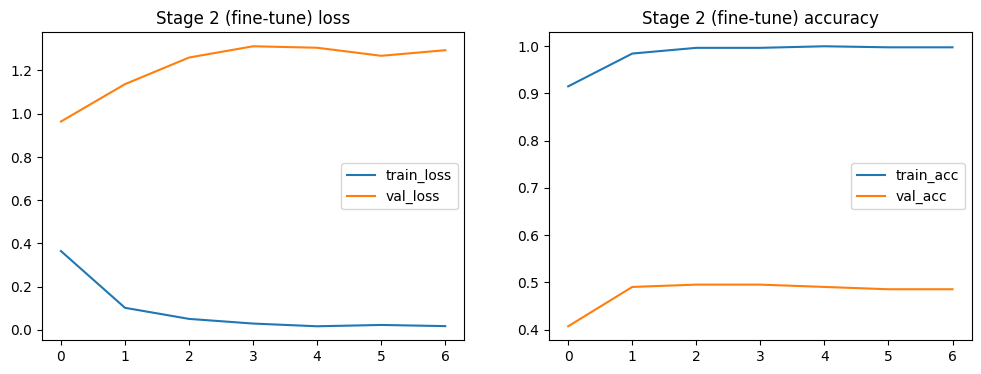

In [11]:
# CELL 10 - plot stage2 
plot_history(history_stage2, "Stage 2 (fine-tune)")


## Evaluate on test

In [ ]:
# predict val probabilities for threshold selection
y_val_prob = model.predict(val_ds).ravel()
# collate y_val true in same order as val_ds
val_y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
print("val_y_true shape:", val_y_true.shape, "y_val_prob shape:", y_val_prob.shape)

# ROC & best threshold on VAL
fpr, tpr, thr = roc_curve(val_y_true, y_val_prob)
roc_auc_val = auc(fpr, tpr)
j_idx = np.argmax(tpr - fpr)
best_thr = thr[j_idx]
print("Val ROC AUC:", roc_auc_val, "Best threshold (Youden) from VAL:", best_thr)

# predict on test
y_test_prob = model.predict(test_ds).ravel()
test_y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
print("test shapes:", test_y_true.shape, y_test_prob.shape)

# get predictions using threshold from val
y_test_pred = (y_test_prob >= best_thr).astype(int)

print("Frame-level Test Metrics:")
print("Accuracy:", accuracy_score(test_y_true, y_test_pred))
print("Precision:", precision_score(test_y_true, y_test_pred, zero_division=0))
print("Recall:", recall_score(test_y_true, y_test_pred, zero_division=0))
print("F1:", f1_score(test_y_true, y_test_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(test_y_true, y_test_pred, zero_division=0))


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 693ms/step
val_y_true shape: (204,) y_val_prob shape: (204,)
Val ROC AUC: 0.20088427527873895 Best threshold (Youden) from VAL: inf
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 654ms/step
test shapes: (302,) (302,)
Frame-level Test Metrics:
Accuracy: 0.6390728476821192
Precision: 0.0
Recall: 0.0
F1: 0.0

Classification Report:
               precision    recall  f1-score   support

           0       0.64      1.00      0.78       193
           1       0.00      0.00      0.00       109

    accuracy                           0.64       302
   macro avg       0.32      0.50      0.39       302
weighted avg       0.41      0.64      0.50       302



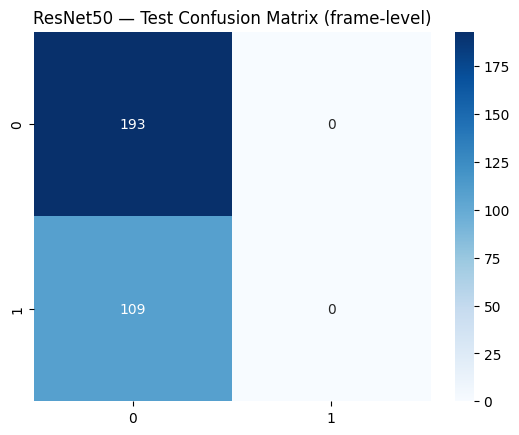

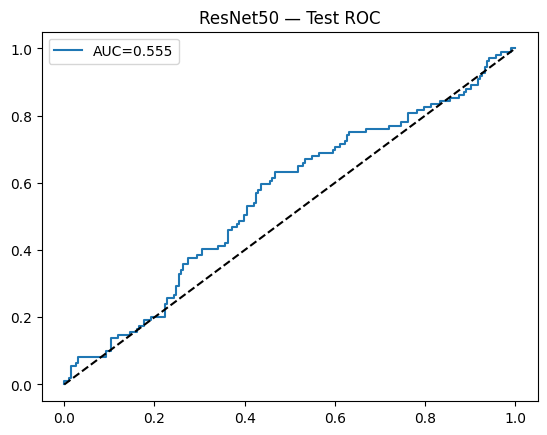

In [ ]:
cm = confusion_matrix(test_y_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("ResNet50 — Test Confusion Matrix (frame-level)")
plt.show()

fpr_t, tpr_t, _ = roc_curve(test_y_true, y_test_prob)
roc_auc_test = auc(fpr_t, tpr_t)
plt.plot(fpr_t, tpr_t, label=f"AUC={roc_auc_test:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ResNet50 — Test ROC")
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.preprocessing import image

def predict_single_image(model, img_path, threshold=0.5, verbose=False):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    prob = float(model.predict(x).ravel()[0])
    pred = int(prob >= threshold)
    label = "FAKE" if pred == 1 else "REAL"
    if verbose:
        print(f"prob={prob:.4f}, pred={pred} -> {label}")
    return {"prob": prob, "pred": pred, "label": label}

# demo on 3 test images (replace with actual paths)
for p in list(test_df['image_path'].values[:3]):
    print(p, predict_single_image(model, p, threshold=best_thr, verbose=True))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
prob=0.6364, pred=0 -> REAL
/home/aryan/code/DeepFakeDetection/data/processed/faces/720/0.jpg {'prob': 0.6363722681999207, 'pred': 0, 'label': 'REAL'}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
prob=0.7833, pred=0 -> REAL
/home/aryan/code/DeepFakeDetection/data/processed/faces/720/1.jpg {'prob': 0.7833266854286194, 'pred': 0, 'label': 'REAL'}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
prob=0.8265, pred=0 -> REAL
/home/aryan/code/DeepFakeDetection/data/processed/faces/720/2.jpg {'prob': 0.82645583152771, 'pred': 0, 'label': 'REAL'}
